# 🎓 EduScore ML: Student Performance Prediction

## Project Overview

EduScore ML is a machine learning regression project that predicts student performance using educational and lifestyle-related features.

The dataset contains information about students such as hours studied, previous scores, participation in extracurricular activities, sleep hours, and the number of sample question papers practiced. The target variable is `Performance Index`, which represents the student's final performance score.

The main goal of this project is to build a simple, interpretable, and accurate regression model that can predict a student's performance index based on these input features. Since the target variable is numerical, this project is a regression problem.

Before building the model, the dataset was explored and cleaned. Duplicate rows were removed, and the categorical column `Extracurricular Activities` was converted into numerical values, where `Yes` was encoded as 1 and `No` was encoded as 0.

After preprocessing, the dataset was divided into training and testing sets. A Linear Regression model was then trained using multiple input features. Although the model is implemented using `LinearRegression()` in scikit-learn, it is considered a Multiple Linear Regression model because it uses several features to predict one numerical target variable.

The model was evaluated using regression metrics such as MAE, RMSE, and R2 Score. Visualizations such as correlation heatmap, actual vs predicted plot, and residual distribution plot were also used to better understand the data and model performance.

# **Importing**

In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# **Loading Data**

In [ ]:
df = pd.read_csv('/kaggle/input/datasets/nikhil7280/student-performance-multiple-linear-regression/Student_Performance.csv')
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


# **Exploratory Data Analysis**

In [119]:
df.shape

(10000, 6)

In [120]:
df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In [121]:
df.duplicated().sum()

np.int64(127)

In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [123]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Hours Studied,10000.0,4.9929,2.589309,1.0,3.0,5.0,7.0,9.0
Previous Scores,10000.0,69.4457,17.343152,40.0,54.0,69.0,85.0,99.0
Sleep Hours,10000.0,6.5306,1.695863,4.0,5.0,7.0,8.0,9.0
Sample Question Papers Practiced,10000.0,4.5833,2.867348,0.0,2.0,5.0,7.0,9.0
Performance Index,10000.0,55.2248,19.212558,10.0,40.0,55.0,71.0,100.0


In [124]:
df.isnull().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


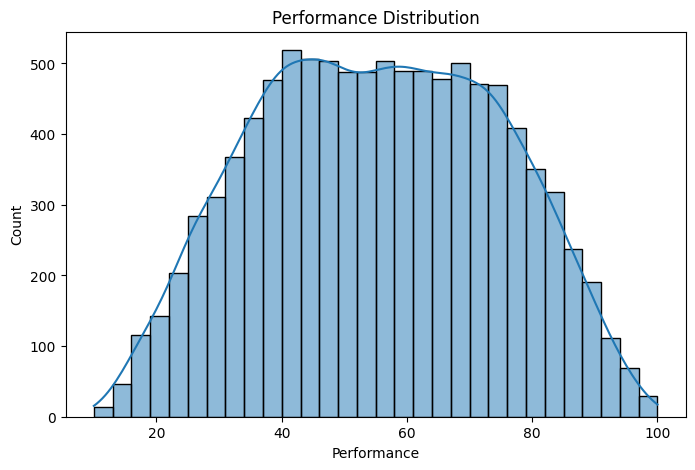

In [125]:
plt.figure(figsize=(8,5))
sns.histplot(df["Performance Index"], bins=30, kde=True)

plt.title("Performance Distribution")
plt.xlabel("Performance")
plt.ylabel("Count")
plt.show()

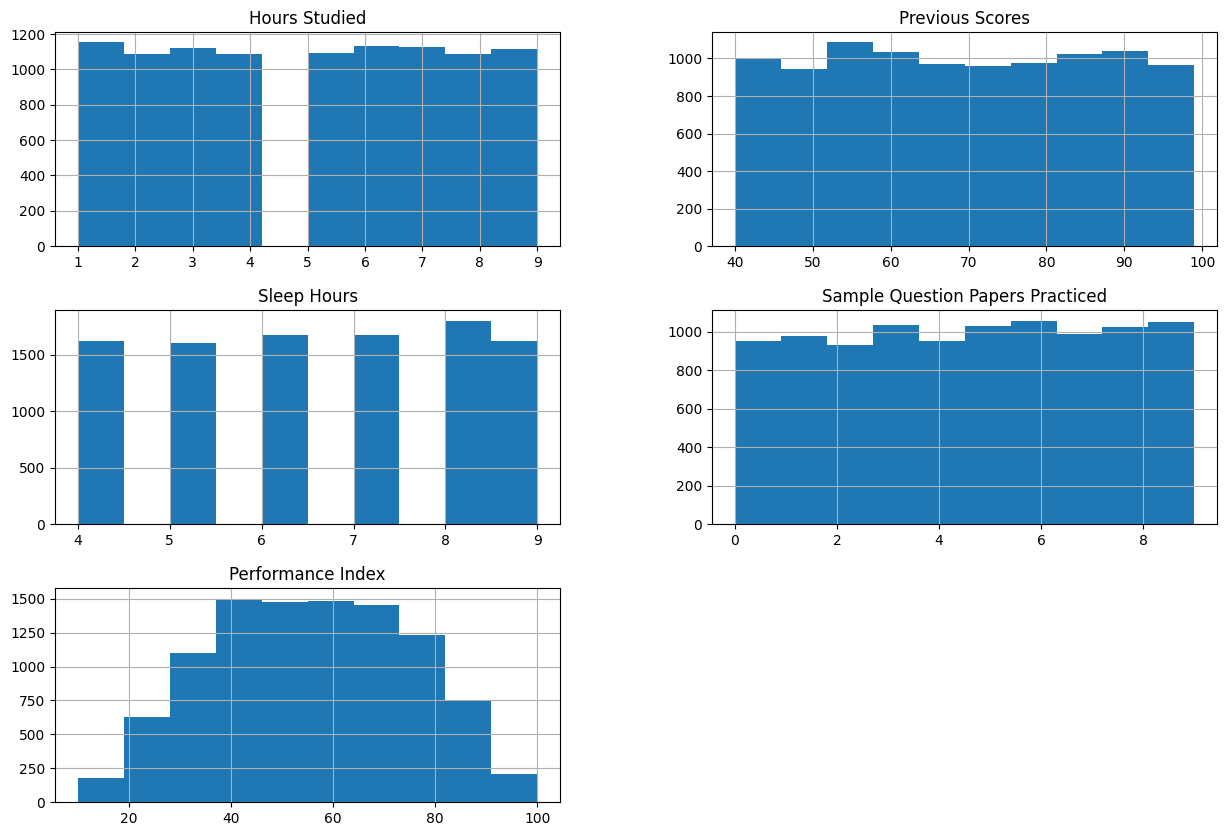

In [126]:
df.hist(figsize=(15,10))
plt.show()

# **Cleaning & Preprocessing Data**

In [127]:
df = df.drop_duplicates()

In [128]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

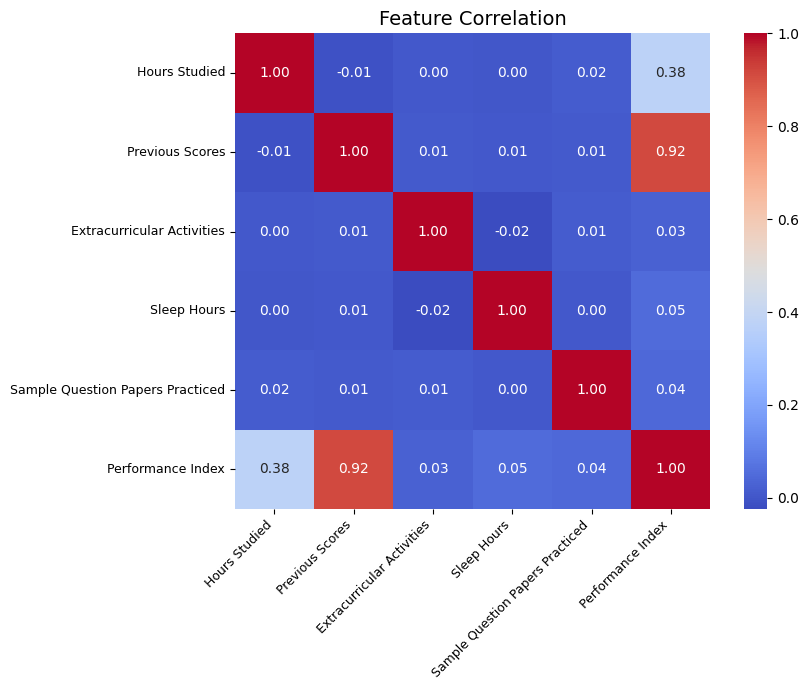

In [129]:
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=True, fmt=".2f", square=True)
plt.title("Feature Correlation", fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

# **Feature & Target Split**

In [130]:
features = [
    "Hours Studied",
    "Previous Scores",
    "Extracurricular Activities",
    "Sleep Hours",
    "Sample Question Papers Practiced"
]

X = df[features]
y = df["Performance Index"]

# **Train & Test Split**

In [131]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Model Training**

**Creating & Training Linear Regression Model**

In [139]:
final_model = LinearRegression(fit_intercept=True)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

In [140]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Final Model: Multiple Linear Regression")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

Final Model: Multiple Linear Regression
MAE: 1.6469703984255573
RMSE: 2.0750664901488047
R2 Score: 0.9884301209927054


**Plot Actual vs Predicted**

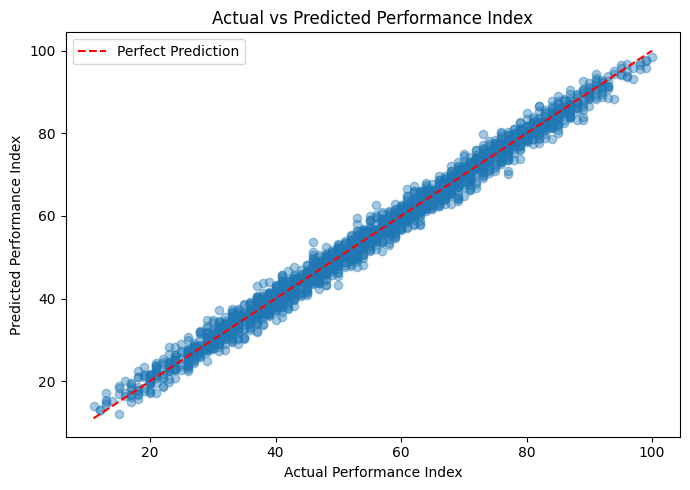

In [135]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--", label="Perfect Prediction")

plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("Actual vs Predicted Performance Index")
plt.tight_layout()
plt.legend()
plt.show()

**Residual Distribution**

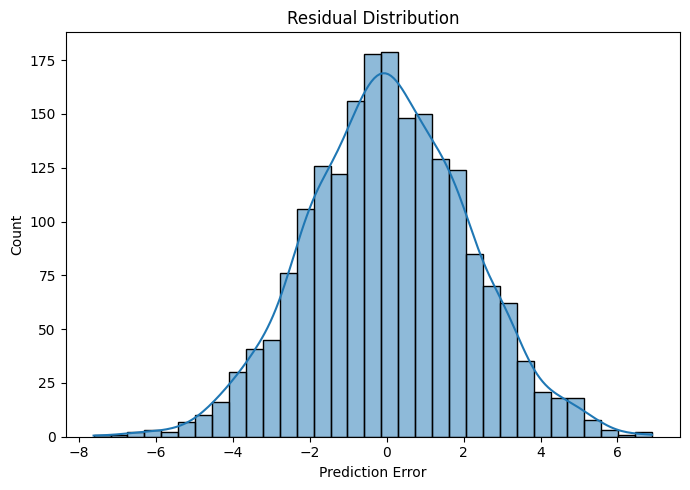

In [136]:
residuals = y_test - y_pred

plt.figure(figsize=(7, 5))
sns.histplot(residuals, kde=True)

plt.xlabel("Prediction Error")
plt.title("Residual Distribution")
plt.tight_layout()
plt.show()

**Fun Little Prediction**

This is a simple example to show how the final model predicts a student's performance index.

In [141]:
sample_student = pd.DataFrame({
    "Hours Studied": [7],
    "Previous Scores": [85],
    "Extracurricular Activities": [1],
    "Sleep Hours": [8],
    "Sample Question Papers Practiced": [5]
})

predicted_score = final_model.predict(sample_student)

print("Predicted Performance Index:", round(predicted_score[0], 2))

Predicted Performance Index: 77.84


# **Final Conclusion**

In this project, a Multiple Linear Regression model was used to predict student performance based on several educational and lifestyle-related features.

The dataset was cleaned by removing duplicate records and converting the categorical feature `Extracurricular Activities` into numerical form. After that, the data was split into training and testing sets.

The final selected model was Linear Regression with `fit_intercept=True`. Since the model uses multiple input features such as previous scores, hours studied, sleep hours, extracurricular activities, and sample question papers practiced, it is considered a Multiple Linear Regression model.

The final model achieved the following results on the test data:

- MAE: 1.65
- RMSE: 2.08
- R2 Score: 0.9884

The R2 Score shows that the model explains about 98.84% of the variation in student performance. The MAE value shows that the model's predictions are off by about 1.65 points on average, and the RMSE value shows that the overall prediction error is about 2.08 points.

Overall, the final Multiple Linear Regression model performed very well on this dataset. The results show that the selected features have a strong relationship with student performance, and a simple regression model can make accurate predictions with small errors.